In [5]:
import matplotlib.pyplot as plt
import os
import numpy as np

FIGURE_FOLDER = 'figures/'
RESULTS_FOLDER = 'results/'

if not os.path.exists(FIGURE_FOLDER): os.mkdir(FIGURE_FOLDER)

In [2]:
def plot_compare_smas(sma_range: list[int], offset_range: list[int] = None, file_str: str = 'mse-{0}-{1}-results.csv', title_prefix: str = "", save: bool = False):    
    if offset_range == None:
        offset_range = sma_range

    xs = offset_range
    colors = ['pink','red','orange','green','blue','grey']

    titles = [
        "Very Close Multiplier for SMAs",
        "Close Multiplier for SMAs",
        "Moderate Multiplier for SMAs",
        "Far Multiplier for SMAs",
        "Validation R^2 for SMAs",
        "Total R^2 for SMAs",
        "Percentage Difference for SMAs"
    ]

    y_labels = [
        "Multiplier Better Than Mean",
        "Multiplier Better Than Mean",
        "Multiplier Better Than Mean",
        "Multiplier Better Than Mean",
        "R^2 Score",
        "R^2 Score",
        "% Difference"
    ]

    data = []

    for _ in titles:
        data.append([])

    for window in sma_range:
        for i in range(len(data)):
            data[i].append([])

        for offset in offset_range:
            with open(RESULTS_FOLDER + file_str.format(window, offset)) as f:
                f.readline()
                
                cur_data = list(map(float, f.readline().split(',')))

                for i in range(len(cur_data)):
                    data[i][-1].append(cur_data[i])

    for i in range(len(titles)):
        plt.title(title_prefix + titles[i])

        for j in range(len(sma_range)):
            plt.plot(xs, data[i][j], label=f"SMA:{sma_range[j]}", color=colors[j], marker='o')

        plt.xlabel("Offset")
        plt.ylabel(y_labels[i])
        plt.legend()

        #if save: 
        #    plt.savefig(FIGURE_FOLDER + file_title + '-mae.png')
        #    plt.close()
        #else: plt.show()

        plt.show()

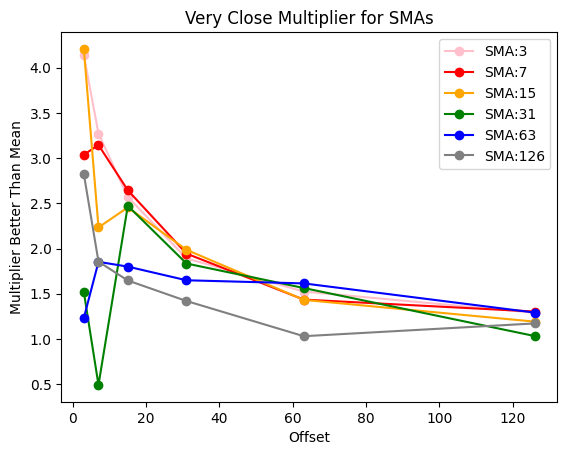

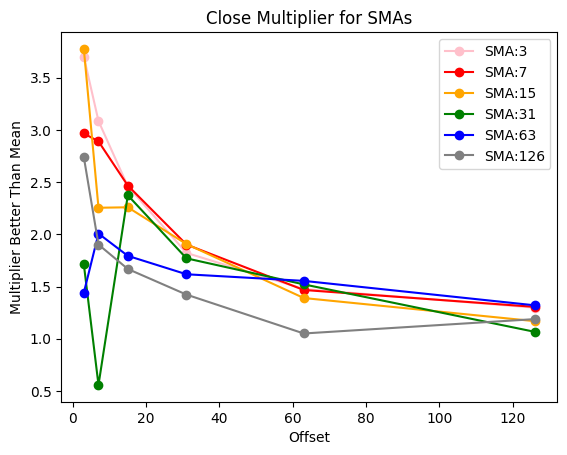

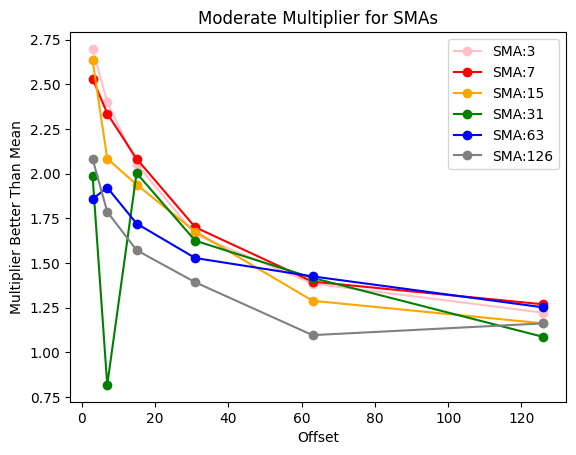

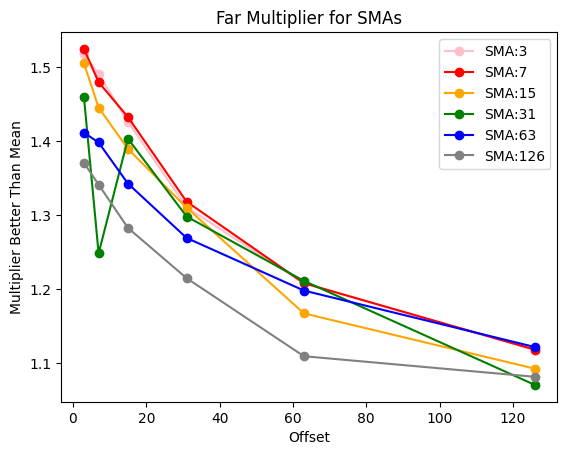

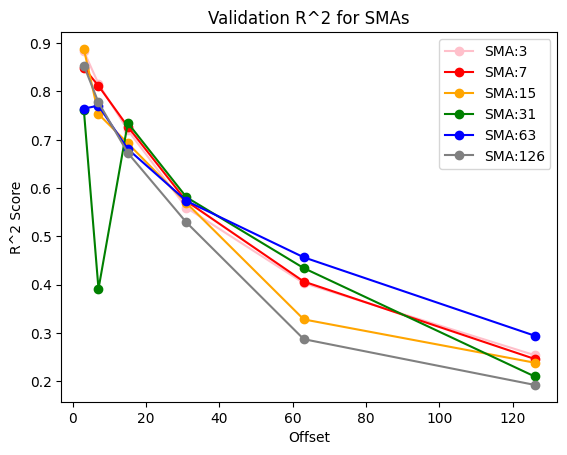

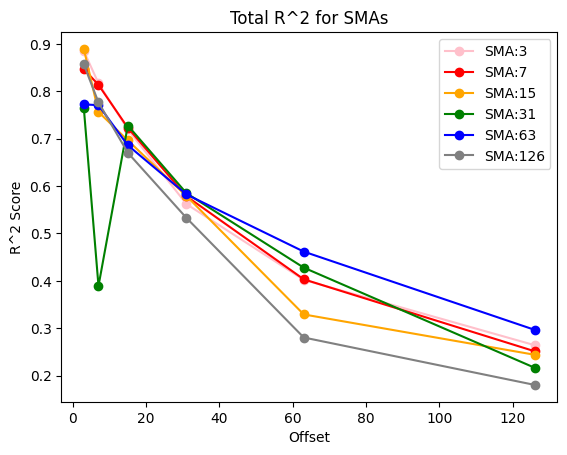

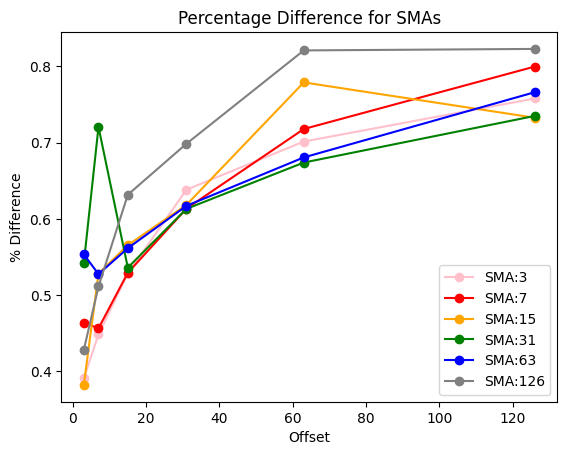

In [3]:
plot_compare_smas([3,7,15,31,63,126])

In [23]:
def single_point_visualizer(file: str, title: str, offset: int):
    data = np.loadtxt(file, delimiter=',')

    X = data[:252,0].reshape((252,))
    Y = data[504:,0].reshape((1,))

    xs = list(range(1,253))

    plt.plot(xs, X, label=f"Feature Prices", color="grey", marker='o')
    plt.plot([ 252 + offset ], Y, label=f"Label Price", color="red", marker='o')

    plt.xlabel("Day")
    plt.ylabel("Mean Centered SMA Price")

    plt.title(title)

    plt.legend()

    plt.show()

    plt.close()

    X = data[252:504,0].reshape((252,))

    plt.plot(xs, X, label=f"Feature RSI", color="grey", marker='o')

    plt.xlabel("Day")
    plt.ylabel("RSI")

    plt.title("RSI " + title)

    plt.legend()

    plt.show()

    plt.close()

In [32]:
def plot_labels(file: str, title: str):
    data = np.loadtxt(file, delimiter=',')

    Y = data[504:,:]
    Y = Y.reshape((Y.shape[1],))
    Y.sort()

    xs = range(0, Y.shape[0])

    plt.plot(xs, Y, label=f"Label Prices", color="red")

    plt.xlabel("Sorted Data Point Index")
    plt.ylabel("Mean Centered Price Value")

    plt.title(title)

    plt.legend()

    plt.show()

    plt.close()

    y_lo = np.percentile(Y, 1)
    y_hi = np.percentile(Y, 99)
    print(f"Clipping Y to [{y_lo:.4f}, {y_hi:.4f}]  (was [{Y.min():.4f}, {Y.max():.4f}])")
    Y = np.clip(Y, y_lo, y_hi)

    plt.plot(xs, Y, label=f"Clipped Label Prices", color="red")

    plt.xlabel("Sorted Data Point Index")
    plt.ylabel("Mean Centered Price Value")

    plt.title("Clipped " + title)

    plt.legend()

    plt.show()

    plt.close()



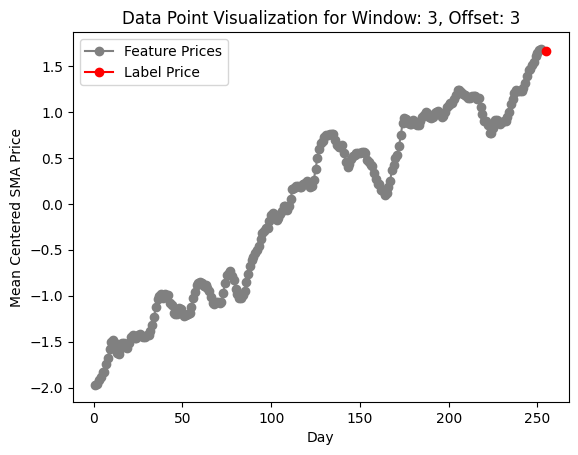

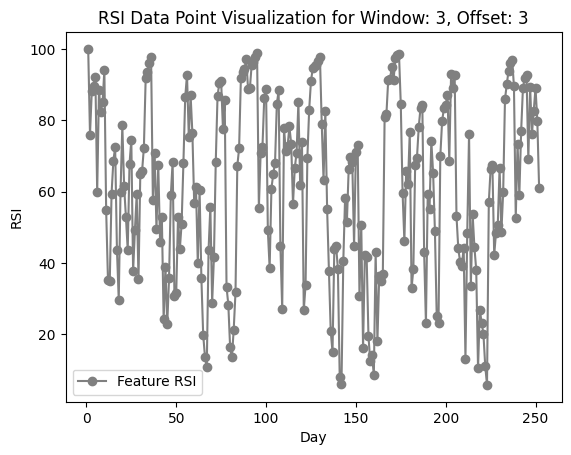

In [29]:
single_point_visualizer('stock_sma_3_3_curated.csv', "Data Point Visualization for Window: 3, Offset: 3", 3)

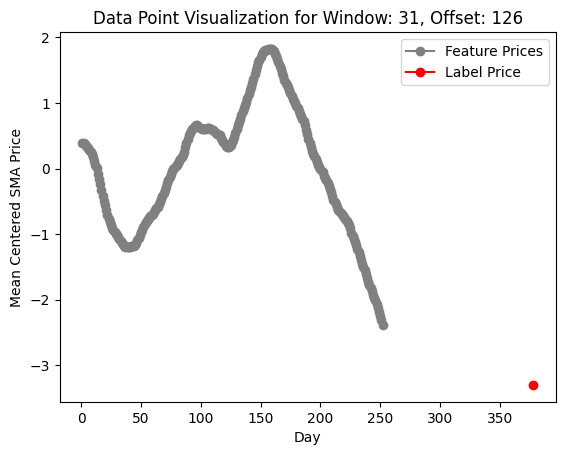

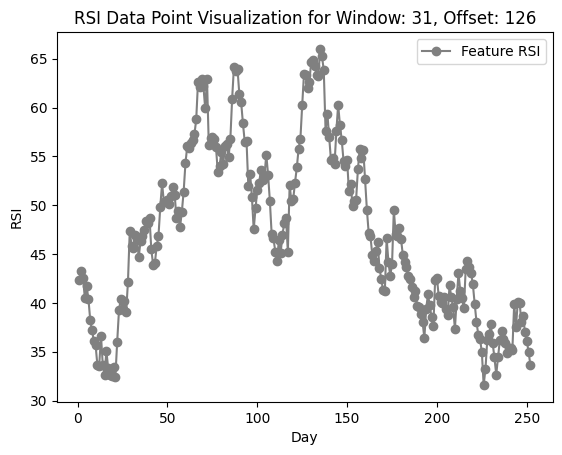

In [30]:
single_point_visualizer('stock_sma_31_126_curated.csv', "Data Point Visualization for Window: 31, Offset: 126", 126)

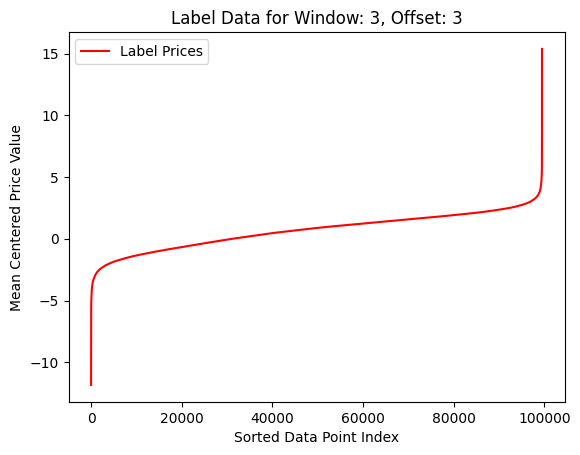

Clipping Y to [-2.8918, 3.4603]  (was [-11.8343, 15.3721])


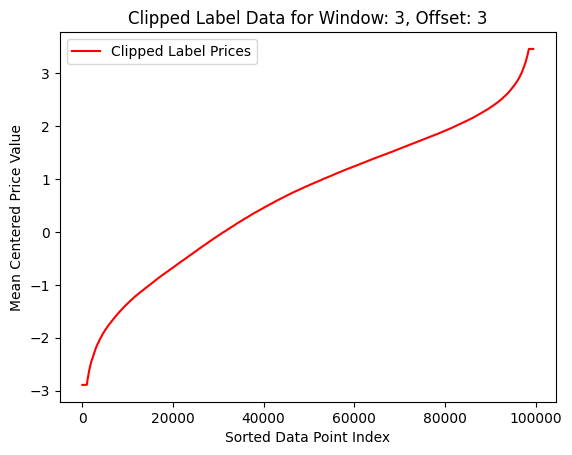

In [33]:
plot_labels('stock_sma_3_3_curated.csv', "Label Data for Window: 3, Offset: 3")